# 🩺 Diabetes Prediction

**Dataset:** Pima Indians Diabetes Database  
**Target:** `Outcome` (0 = Tidak diabetes, 1 = Diabetes)  
**Task:** Binary Classification

---

### Pipeline Overview
1. EDA & Validasi Kualitas Data
2. Train/Test Split (DILAKUKAN PERTAMA — anti-leakage)
3. Preprocessing & Imputasi (fit hanya pada train)
4. Feature Engineering (custom transformer)
5. Feature Selection (fit hanya pada train)
6. Model Benchmarking (CV)
7. Hyperparameter Tuning + SMOTE
8. Kalibrasi Probabilitas
9. Optimasi Threshold (via CV, minimasi FP)
10. Evaluasi & Interpretasi (SHAP)
11. Export Model (Pipeline End-to-End yang terima raw data)


In [46]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, precision_recall_curve,
    ConfusionMatrixDisplay, average_precision_score,
    precision_score, recall_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
import joblib
import json, os

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
SEED = 42
np.random.seed(SEED)
print('Library siap!')

Library siap!


---
## 1. Load Data & EDA

In [47]:
df = pd.read_csv('./dataset/diabetes.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
print('=== Info ===')
df.info()
print('\n=== Missing values (NaN) ===')
print(df.isnull().sum())
print('\n=== Statistik deskriptif ===')
df.describe().T

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Missing values (NaN) ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeF

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [49]:
ZERO_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('⚠️  Zero values (sebenarnya missing data):')
for col in ZERO_COLS:
    n = (df[col] == 0).sum()
    pct = n / len(df) * 100
    print(f'  {col:25s}: {n:3d} ({pct:.1f}%)')

⚠️  Zero values (sebenarnya missing data):
  Glucose                  :   5 (0.7%)
  BloodPressure            :  35 (4.6%)
  SkinThickness            : 227 (29.6%)
  Insulin                  : 374 (48.7%)
  BMI                      :  11 (1.4%)


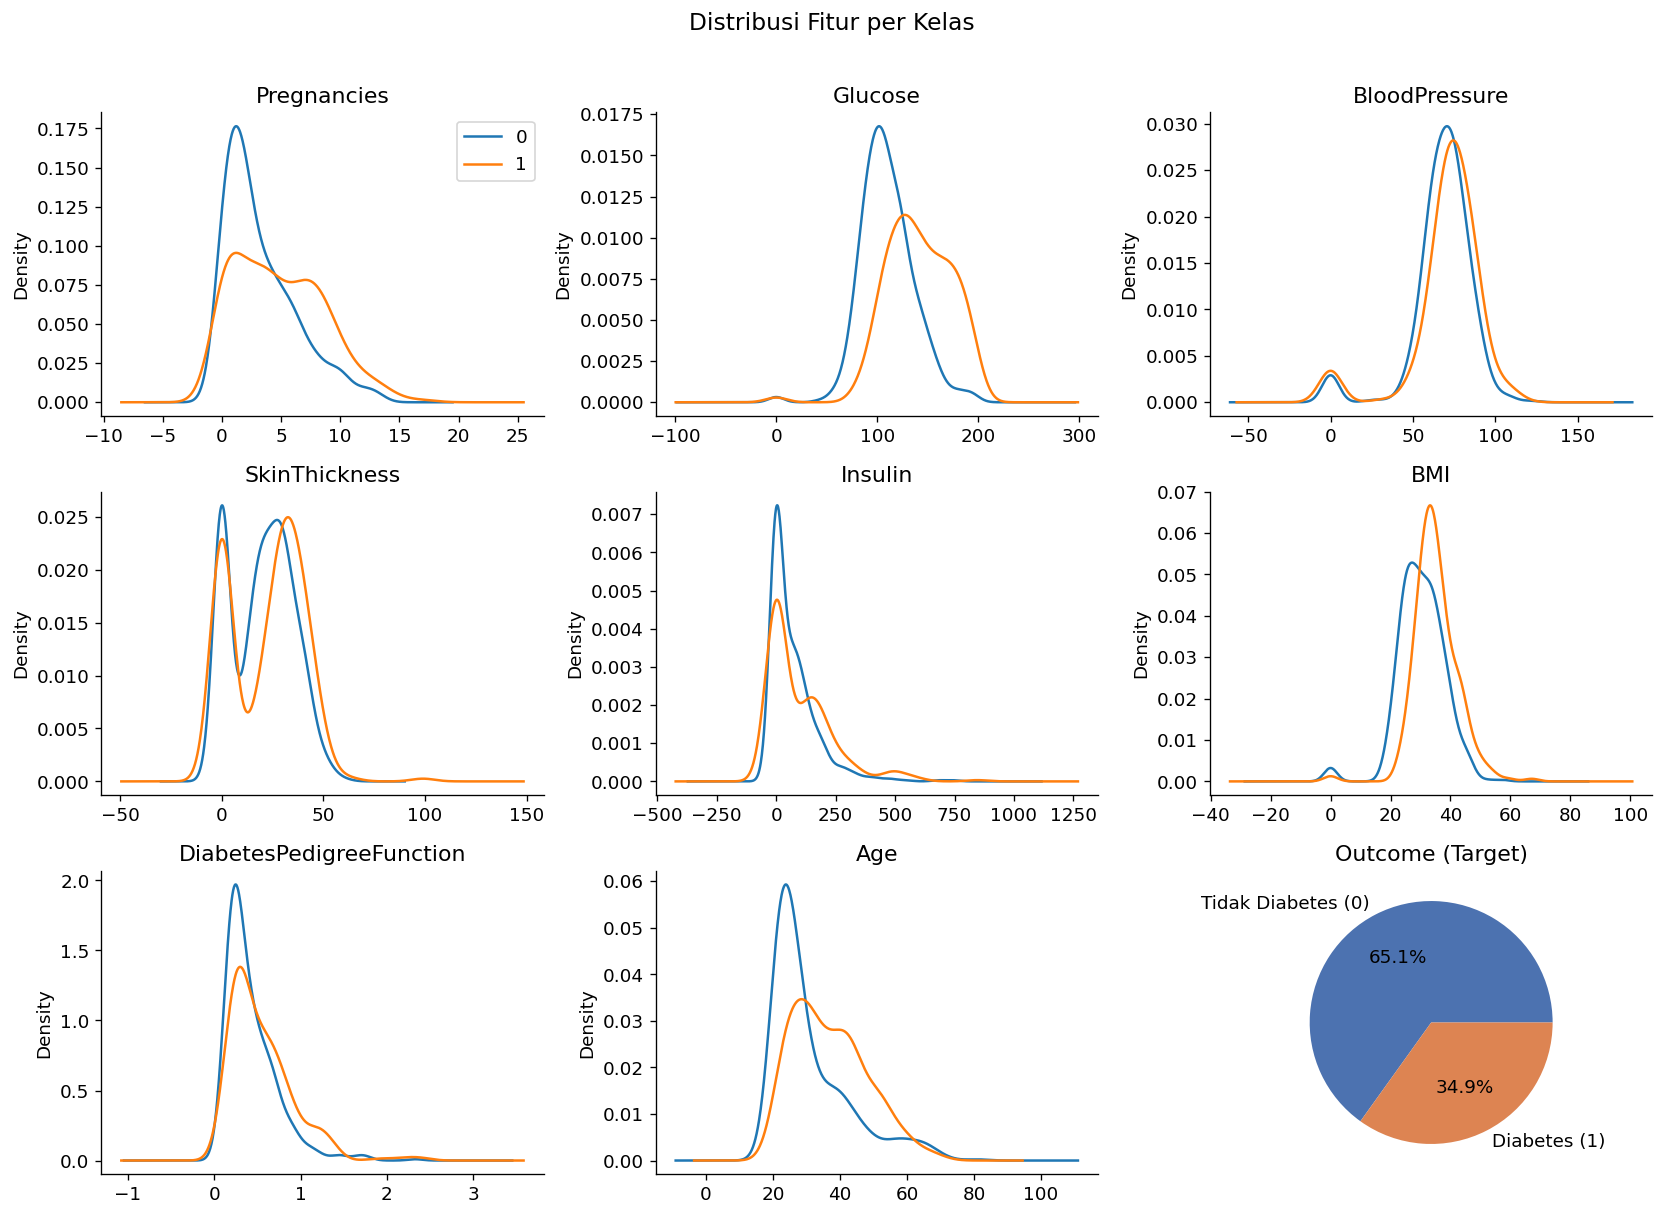

In [50]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

features = df.columns.tolist()
for i, feat in enumerate(features):
    if feat == 'Outcome':
        axes[i].pie(
            df['Outcome'].value_counts(),
            labels=['Tidak Diabetes (0)', 'Diabetes (1)'],
            autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452']
        )
        axes[i].set_title('Outcome (Target)')
    else:
        df.groupby('Outcome')[feat].plot.kde(ax=axes[i], legend=(i == 0))
        axes[i].set_title(feat)
        axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur per Kelas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

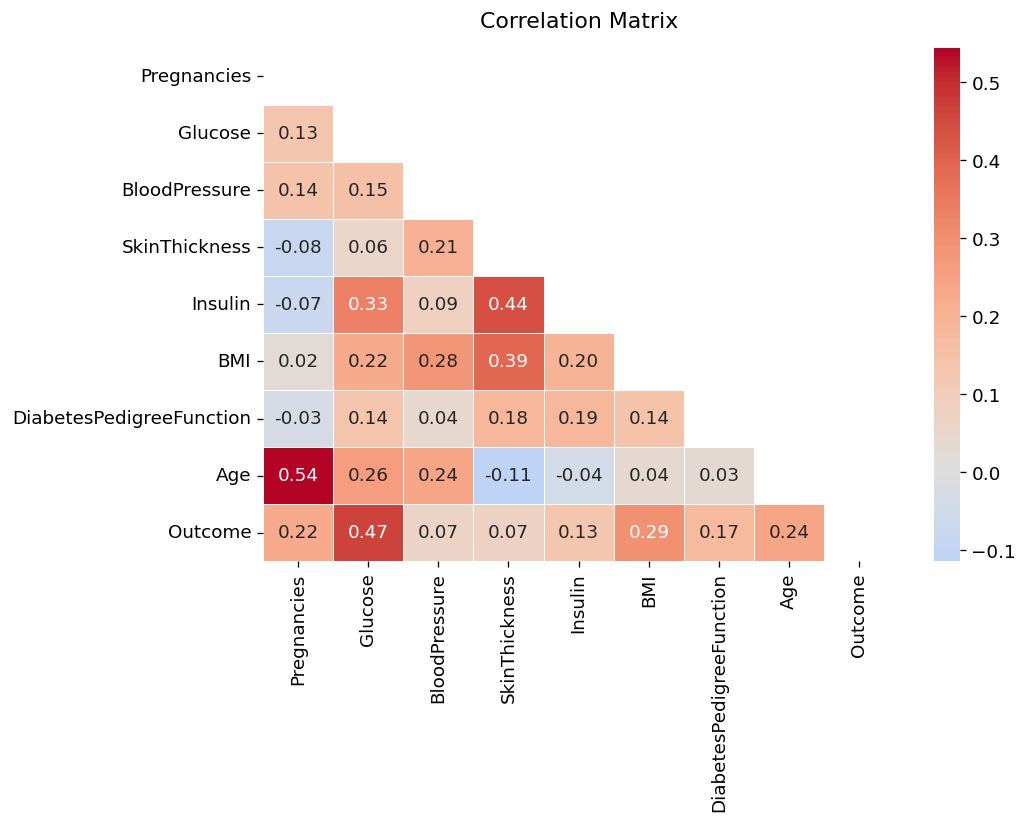

In [51]:
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(
    df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=.5, ax=ax
)
ax.set_title('Correlation Matrix', pad=12)
plt.tight_layout()
plt.show()

---
## 2. Train/Test Split — DILAKUKAN PERTAMA


In [52]:
X_raw = df.drop('Outcome', axis=1).copy()
y = df['Outcome'].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Proporsi kelas train — 0: {(y_train==0).mean():.2%}  1: {(y_train==1).mean():.2%}')
print(f'Proporsi kelas test  — 0: {(y_test==0).mean():.2%}  1: {(y_test==1).mean():.2%}')

Train: (614, 8)  |  Test: (154, 8)
Proporsi kelas train — 0: 65.15%  1: 34.85%
Proporsi kelas test  — 0: 64.94%  1: 35.06%


---
## 3. Custom Transformers untuk Pipeline yang Bersih

Membungkus semua preprocessing ke dalam sklearn Transformer agar bisa  
dijadikan satu Pipeline yang dapat di-export dan digunakan langsung pada raw data.

In [ ]:
class ZeroToNanImputer(BaseEstimator, TransformerMixin):
    def __init__(self, zero_cols=None):
        self.zero_cols = zero_cols or []

    def fit(self, X, y=None):
        return self  

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if hasattr(X, 'columns'):
            for col in self.zero_cols:
                if col in X.columns:
                    X[col] = X[col].replace(0, np.nan)
        return X


class WinsorizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
        self.bounds_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            self.bounds_[col] = (
                float(X[col].quantile(self.lower)),
                float(X[col].quantile(self.upper))
            )
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col, (low, high) in self.bounds_.items():
            if col in X.columns:
                X[col] = X[col].clip(low, high)
        return X


class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self  

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if 'Glucose' in X.columns and 'BMI' in X.columns:
            X['Glucose_BMI'] = X['Glucose'] * X['BMI']
        if 'Glucose' in X.columns and 'Age' in X.columns:
            X['Glucose_Age'] = X['Glucose'] * X['Age']
        if 'Insulin' in X.columns and 'Glucose' in X.columns:
            X['Insulin_Glucose'] = X['Insulin'] / (X['Glucose'] + 1)
        if 'BMI' in X.columns:
            X['BMI_squared'] = X['BMI'] ** 2
            X['BMI_cat'] = pd.cut(
                X['BMI'],
                bins=[0, 18.5, 25, 30, np.inf],
                labels=[0, 1, 2, 3]
            ).astype(float)
        if 'Age' in X.columns:
            X['Age_group'] = pd.cut(
                X['Age'],
                bins=[0, 30, 45, 60, np.inf],
                labels=[0, 1, 2, 3]
            ).astype(float)
        return X


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns

    def fit(self, X, y=None):
        if self.columns is None:
            X_df = pd.DataFrame(X)
            selector = SelectKBest(f_classif, k='all')
            selector.fit(X_df, y)
            scores = pd.Series(selector.scores_, index=X_df.columns)
            self.columns_ = scores[scores >= scores.mean()].index.tolist()
        else:
            self.columns_ = self.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        available = [c for c in self.columns_ if c in X.columns]
        return X[available]


print('✅ Custom transformers siap!')

✅ Custom transformers siap!


---
## 4. Bangun Preprocessing Pipeline

Fit **hanya** pada train set. Test set akan di-transform saja.

In [54]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

preprocessor = Pipeline(steps=[
    ('zero_to_nan',  ZeroToNanImputer(zero_cols=ZERO_COLS)),
    ('imputer',      IterativeImputer(random_state=SEED, max_iter=10)),
    ('winsorizer',   WinsorizerTransformer(lower=0.01, upper=0.99)),
    ('feat_eng',     FeatureEngineeringTransformer()),
    ('selector',     ColumnSelector()),   
    ('scaler',       StandardScaler()),
])

X_train_proc = preprocessor.fit_transform(X_train_raw, y_train)
X_test_proc  = preprocessor.transform(X_test_raw)

selected_features = preprocessor.named_steps['selector'].columns_

print(f'Fitur terpilih ({len(selected_features)}): {selected_features}')
print(f'Train processed: {X_train_proc.shape}')
print(f'Test processed:  {X_test_proc.shape}')
print(f'Missing values train: {np.isnan(X_train_proc).sum()}')

Fitur terpilih (3): [1, 4, 5]
Train processed: (614, 3)
Test processed:  (154, 3)
Missing values train: 0


---
## 5. Model Benchmarking (5-Fold Stratified CV)

Scoring tambahan: **Average Precision** — lebih informatif dari AUC pada data imbalanced  
dan lebih relevan untuk analisis false positive.

In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=SEED),
    'XGBoost':             xgb.XGBClassifier(eval_metric='logloss', random_state=SEED, verbosity=0),
    'LightGBM':            lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'SVM (RBF)':           SVC(probability=True, class_weight='balanced', random_state=SEED),
}

bench_results = {}
print(f'{"Model":25s}  {"ROC-AUC":>13s}  {"Avg Prec":>13s}  {"Precision":>13s}  {"Recall":>13s}')
print('-' * 84)
for name, model in base_models.items():
    auc  = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='roc_auc')
    ap   = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='average_precision')
    prec = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='precision')
    rec  = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='recall')
    bench_results[name] = {
        'AUC': auc.mean(), 'AP': ap.mean(),
        'Prec': prec.mean(), 'Rec': rec.mean(),
    }
    print(f'{name:25s}  {auc.mean():.4f}±{auc.std():.3f}  {ap.mean():.4f}±{ap.std():.3f}  '
          f'{prec.mean():.4f}±{prec.std():.3f}  {rec.mean():.4f}±{rec.std():.3f}')

Model                            ROC-AUC       Avg Prec      Precision         Recall
------------------------------------------------------------------------------------
Logistic Regression        0.8274±0.025  0.7401±0.055  0.7399±0.077  0.5749±0.025
Random Forest              0.7803±0.022  0.6582±0.027  0.6675±0.033  0.5466±0.055
Extra Trees                0.7682±0.027  0.6382±0.035  0.6407±0.031  0.5188±0.041
XGBoost                    0.7501±0.036  0.6291±0.034  0.6040±0.056  0.5604±0.051
LightGBM                   0.7649±0.025  0.6424±0.028  0.6162±0.061  0.5374±0.033
Gradient Boosting          0.7731±0.025  0.6589±0.041  0.6295±0.068  0.5188±0.041
SVM (RBF)                  0.8119±0.024  0.7067±0.033  0.6132±0.037  0.7148±0.041


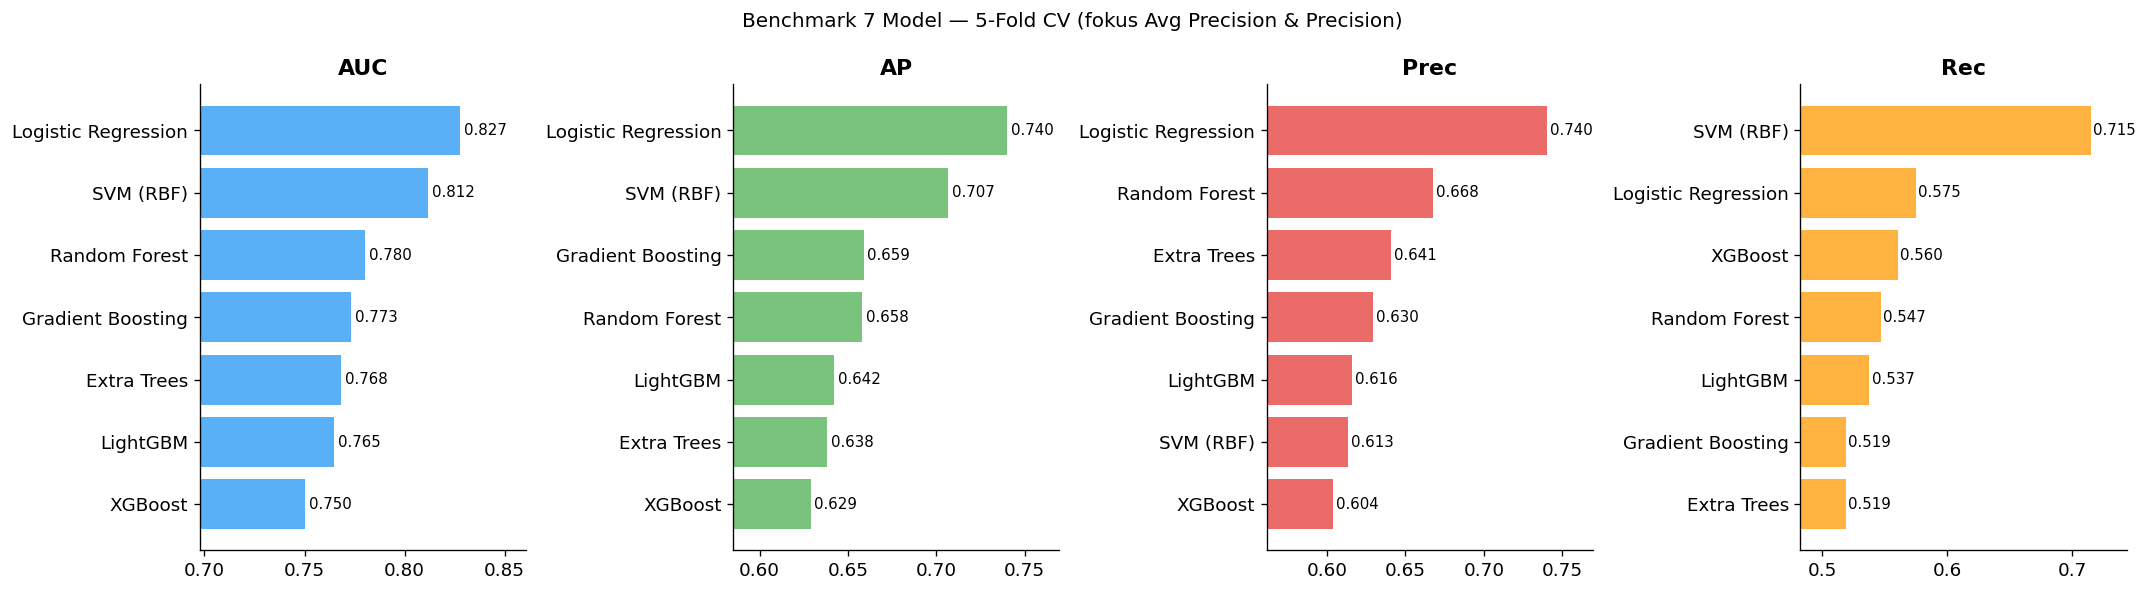

Top-4 untuk base learner stacking (by Avg Precision):
  1. Logistic Regression        AP=0.7401
  2. SVM (RBF)                  AP=0.7067
  3. Gradient Boosting          AP=0.6589
  4. Random Forest              AP=0.6582


In [56]:
bench_df = pd.DataFrame(bench_results).T[['AUC', 'AP', 'Prec', 'Rec']]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#2196F3', '#4CAF50', '#E53935', '#FF9800']
for ax, (metric, color) in zip(axes, zip(['AUC', 'AP', 'Prec', 'Rec'], colors)):
    vals = bench_df[metric].sort_values()
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.75)
    ax.set_xlim(vals.min() * 0.93, min(1.0, vals.max() * 1.04))
    ax.set_title(metric, fontweight='bold')
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
plt.suptitle('Benchmark 7 Model — 5-Fold CV (fokus Avg Precision & Precision)', fontsize=12)
plt.tight_layout(); plt.show()

top4 = bench_df.sort_values('AP', ascending=False).head(4).index.tolist()
print(f'Top-4 untuk base learner stacking (by Avg Precision):')
for i, name in enumerate(top4, 1):
    print(f'  {i}. {name:25s}  AP={bench_results[name]["AP"]:.4f}')

---
## 6. Hyperparameter Tuning + SMOTE

SMOTE diterapkan **di dalam** setiap fold CV (via `ImbPipeline`) agar tidak terjadi  
leakage data sintetis ke validation fold.

In [57]:
# XGBoost
rs_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=SEED, verbosity=0),
    {
        'n_estimators':     [100, 200, 300, 500],
        'max_depth':        [3, 4, 5, 6],
        'learning_rate':    [0.01, 0.05, 0.1, 0.15],
        'subsample':        [0.6, 0.7, 0.8, 0.9],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
        'gamma':            [0, 0.1, 0.2, 0.5],
        'min_child_weight': [1, 3, 5],
        'reg_alpha':        [0, 0.01, 0.1, 0.5],
        'reg_lambda':       [0.5, 1, 1.5, 2],
        'scale_pos_weight': [1, 1.5, 2],
    },
    n_iter=60, scoring='average_precision', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
rs_xgb.fit(X_train_proc, y_train)
print(f'XGBoost      Best AP: {rs_xgb.best_score_:.4f}')

XGBoost      Best AP: 0.7239


In [58]:
# LightGBM
rs_lgb = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=SEED, verbose=-1),
    {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [-1, 4, 6, 8],
        'learning_rate':     [0.01, 0.05, 0.1, 0.15],
        'num_leaves':        [15, 31, 63, 127],
        'subsample':         [0.6, 0.7, 0.8, 0.9],
        'colsample_bytree':  [0.6, 0.7, 0.8, 0.9],
        'reg_alpha':         [0, 0.01, 0.1, 0.5],
        'reg_lambda':        [0, 0.01, 0.1, 1],
        'min_child_samples': [10, 20, 30, 50],
        'class_weight':      ['balanced', None],
    },
    n_iter=60, scoring='average_precision', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
rs_lgb.fit(X_train_proc, y_train)
print(f'LightGBM     Best AP: {rs_lgb.best_score_:.4f}')

LightGBM     Best AP: 0.7211


In [59]:
# Random Forest
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED),
    {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2'],
        'class_weight':      ['balanced', 'balanced_subsample'],
    },
    n_iter=50, scoring='average_precision', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
rs_rf.fit(X_train_proc, y_train)
print(f'RandomForest Best AP: {rs_rf.best_score_:.4f}')

RandomForest Best AP: 0.7137


In [60]:
# Extra Trees
rs_et = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=SEED),
    {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2'],
        'class_weight':      ['balanced', 'balanced_subsample'],
    },
    n_iter=50, scoring='average_precision', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
rs_et.fit(X_train_proc, y_train)
print(f'ExtraTrees   Best AP: {rs_et.best_score_:.4f}')

# Gradient Boosting
rs_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    {
        'n_estimators':  [100, 200, 300],
        'max_depth':     [2, 3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample':     [0.7, 0.8, 0.9, 1.0],
        'max_features':  ['sqrt', 'log2', None],
    },
    n_iter=40, scoring='average_precision', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
rs_gb.fit(X_train_proc, y_train)
print(f'GradBoosting Best AP: {rs_gb.best_score_:.4f}')

tuning_summary = {
    'XGBoost': rs_xgb.best_score_, 'LightGBM': rs_lgb.best_score_,
    'Random Forest': rs_rf.best_score_, 'Extra Trees': rs_et.best_score_,
    'Grad Boosting': rs_gb.best_score_,
}
print('\nRingkasan Tuning:')
for name, score in sorted(tuning_summary.items(), key=lambda x: -x[1]):
    print(f'  {name:20s}: {score:.4f}')

ExtraTrees   Best AP: 0.7349
GradBoosting Best AP: 0.7392

Ringkasan Tuning:
  Grad Boosting       : 0.7392
  Extra Trees         : 0.7349
  XGBoost             : 0.7239
  LightGBM            : 0.7211
  Random Forest       : 0.7137


---
## 7. Stacking Ensemble

### Arsitektur Stacking

```
Preprocessed Data
        │
   ┌────┴────────────────────────────┐  Level-0 (Base Learners)
   │  XGBoost       (tuned)  → prob │
   │  LightGBM      (tuned)  → prob │  OOF predict_proba
   │  Random Forest (tuned)  → prob │  (5-fold internal)
   │  Extra Trees   (tuned)  → prob │
   │  Grad Boosting (tuned)  → prob │
   └─────────────────────────────────┘
        │ + passthrough (fitur asli)
   ┌────┴────────────────────────────┐  Level-1 (Meta-Learner)
   │  LogisticRegression             │
   │  (C=0.1, class_weight=balanced) │  → probabilitas final
   └─────────────────────────────────┘
```
- **`stack_method='predict_proba'`** — meta-learner menerima probabilitas (soft voting)
- **`passthrough=True`** — meta-learner juga melihat fitur asli, bukan hanya output base
- **Meta-learner C=0.1** — regularisasi kuat agar tidak overfit pada output base models
- **SMOTE sebelum fit** — latih base models pada data yang lebih seimbang

In [61]:
estimators_level0 = [
    ('xgb', xgb.XGBClassifier(
        **rs_xgb.best_params_,
        eval_metric='logloss', random_state=SEED, verbosity=0)),
    ('lgb', lgb.LGBMClassifier(
        **rs_lgb.best_params_,
        random_state=SEED, verbose=-1)),
    ('rf', RandomForestClassifier(
        **rs_rf.best_params_, random_state=SEED)),
    ('et', ExtraTreesClassifier(
        **rs_et.best_params_, random_state=SEED)),
    ('gb', GradientBoostingClassifier(
        **rs_gb.best_params_, random_state=SEED)),
]

meta_learner = LogisticRegression(
    C=0.1, max_iter=2000, class_weight='balanced', random_state=SEED
)

stacking_clf = StackingClassifier(
    estimators=estimators_level0,
    final_estimator=meta_learner,
    stack_method='predict_proba',
    passthrough=True,
    cv=5,
    n_jobs=-1
)
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print(f'Sebelum SMOTE: {X_train_proc.shape[0]} sampel | {y_train.value_counts().to_dict()}')
print(f'Setelah SMOTE: {X_train_smote.shape[0]} sampel | {pd.Series(y_train_smote).value_counts().to_dict()}')

print('\nFitting Stacking Ensemble...')
stacking_clf.fit(X_train_smote, y_train_smote)
print('Stacking selesai!')

Sebelum SMOTE: 614 sampel | {0: 400, 1: 214}
Setelah SMOTE: 800 sampel | {0: 400, 1: 400}

Fitting Stacking Ensemble...
Stacking selesai!


---
## 8. Perbandingan: Individual Terbaik vs Stacking Ensemble

In [62]:
stack_auc  = cross_val_score(stacking_clf, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
stack_ap   = cross_val_score(stacking_clf, X_train_smote, y_train_smote, cv=cv, scoring='average_precision')
stack_prec = cross_val_score(stacking_clf, X_train_smote, y_train_smote, cv=cv, scoring='precision')
stack_rec  = cross_val_score(stacking_clf, X_train_smote, y_train_smote, cv=cv, scoring='recall')

best_ind_name = max(tuning_summary, key=tuning_summary.get)
best_ind_map  = {
    'XGBoost': rs_xgb.best_estimator_,
    'LightGBM': rs_lgb.best_estimator_,
    'Random Forest': rs_rf.best_estimator_,
    'Extra Trees': rs_et.best_estimator_,
    'Grad Boosting': rs_gb.best_estimator_,
}
best_ind_model = best_ind_map[best_ind_name]

ind_auc  = cross_val_score(best_ind_model, X_train_smote, y_train_smote, cv=cv, scoring='roc_auc')
ind_ap   = cross_val_score(best_ind_model, X_train_smote, y_train_smote, cv=cv, scoring='average_precision')
ind_prec = cross_val_score(best_ind_model, X_train_smote, y_train_smote, cv=cv, scoring='precision')
ind_rec  = cross_val_score(best_ind_model, X_train_smote, y_train_smote, cv=cv, scoring='recall')

compare_df = pd.DataFrame({
    f'{best_ind_name} (Individual)': {
        'ROC-AUC':       f'{ind_auc.mean():.4f} ± {ind_auc.std():.4f}',
        'Avg Precision': f'{ind_ap.mean():.4f} ± {ind_ap.std():.4f}',
        'Precision':     f'{ind_prec.mean():.4f} ± {ind_prec.std():.4f}',
        'Recall':        f'{ind_rec.mean():.4f} ± {ind_rec.std():.4f}',
    },
    'Stacking Ensemble (5 models)': {
        'ROC-AUC':       f'{stack_auc.mean():.4f} ± {stack_auc.std():.4f}',
        'Avg Precision': f'{stack_ap.mean():.4f} ± {stack_ap.std():.4f}',
        'Precision':     f'{stack_prec.mean():.4f} ± {stack_prec.std():.4f}',
        'Recall':        f'{stack_rec.mean():.4f} ± {stack_rec.std():.4f}',
    }
}).T

print('Perbandingan CV (SMOTE data):')
print(compare_df.to_string())

if stack_ap.mean() >= ind_ap.mean():
    final_model_uncal = stacking_clf
    final_model_name  = 'Stacking Ensemble'
    print(f'\nFinal model: Stacking Ensemble (AP={stack_ap.mean():.4f})')
else:
    final_model_uncal = best_ind_model
    final_model_name  = best_ind_name
    print(f'\nFinal model: {best_ind_name} (AP={ind_ap.mean():.4f})')

Perbandingan CV (SMOTE data):
                                      ROC-AUC    Avg Precision        Precision           Recall
Grad Boosting (Individual)    0.8402 ± 0.0150  0.8363 ± 0.0275  0.7285 ± 0.0240  0.8000 ± 0.0632
Stacking Ensemble (5 models)  0.8397 ± 0.0200  0.8379 ± 0.0299  0.7530 ± 0.0164  0.6950 ± 0.0534

Final model: Stacking Ensemble (AP=0.8379)


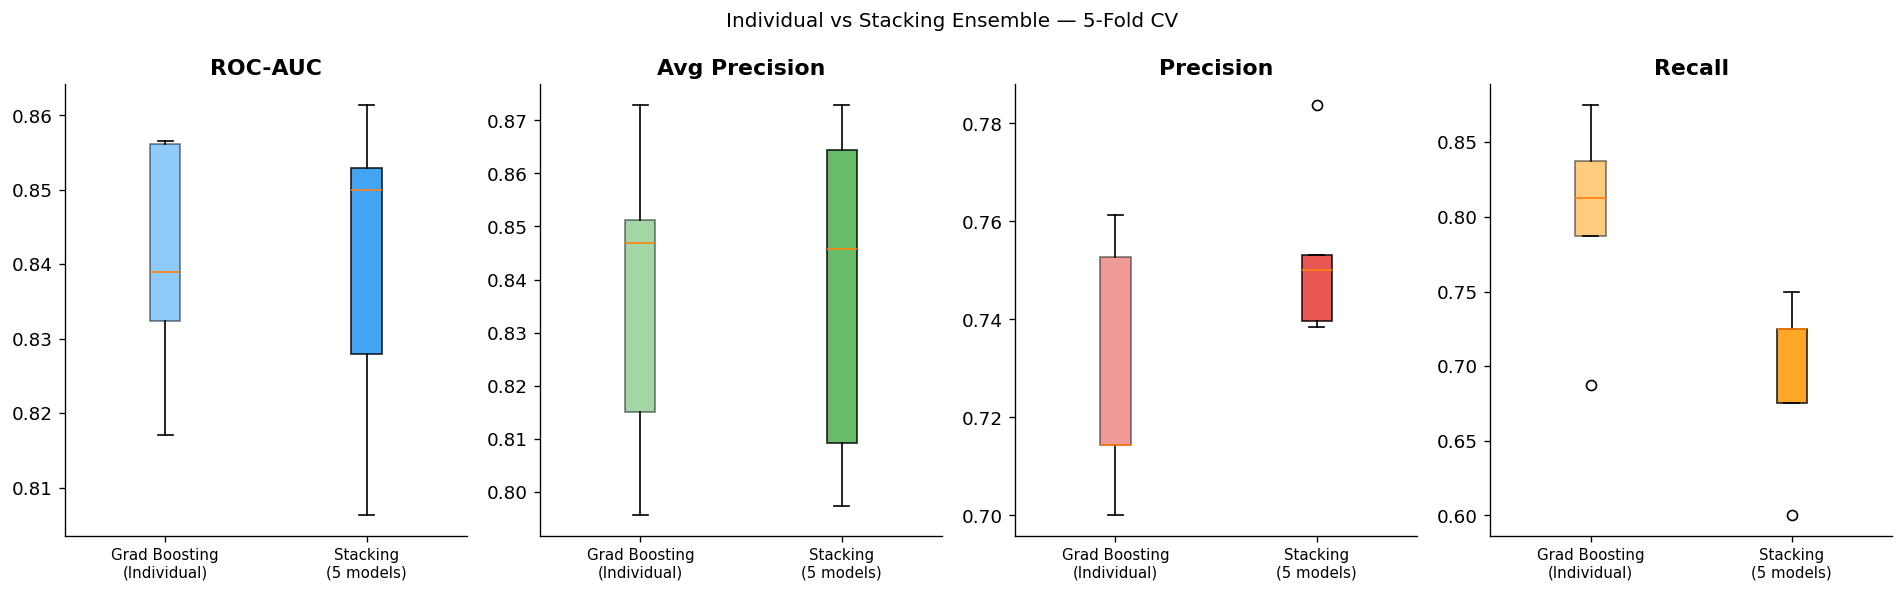

In [63]:
metrics_compare = {
    'ROC-AUC':       ([ind_auc,  stack_auc],  '#2196F3'),
    'Avg Precision': ([ind_ap,   stack_ap],   '#4CAF50'),
    'Precision':     ([ind_prec, stack_prec], '#E53935'),
    'Recall':        ([ind_rec,  stack_rec],  '#FF9800'),
}
labels_bp = [f'{best_ind_name}\n(Individual)', 'Stacking\n(5 models)']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, (metric, (data, color)) in zip(axes, metrics_compare.items()):
    bp = ax.boxplot(data, labels=labels_bp, patch_artist=True)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(color)
        patch.set_alpha(0.5 if i == 0 else 0.85)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)
plt.suptitle('Individual vs Stacking Ensemble — 5-Fold CV', fontsize=12)
plt.tight_layout(); plt.show()

---
## 9. Kalibrasi Probabilitas

Model tree-based (XGBoost, RF) cenderung **overconfident** — probabilitasnya tidak  
terkalibrasi dengan baik. `CalibratedClassifierCV` dengan metode isotonic regression  
memperbaiki ini, sehingga threshold yang kita pilih lebih reliable pada data baru.

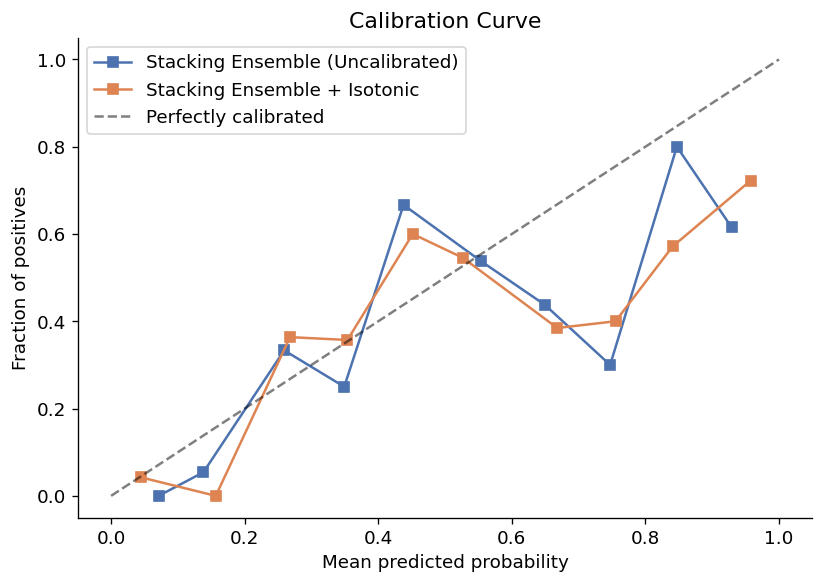

AUC sebelum kalibrasi: 0.7852
AUC setelah kalibrasi: 0.7826


In [64]:
calibrated_model = CalibratedClassifierCV(
    final_model_uncal, method='isotonic', cv=5
)
calibrated_model.fit(X_train_smote, y_train_smote)

y_prob_test_raw = final_model_uncal.predict_proba(X_test_proc)[:, 1]
y_prob_test_cal = calibrated_model.predict_proba(X_test_proc)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for probs, label, color in [
    (y_prob_test_raw, f'{final_model_name} (Uncalibrated)', '#4C72B0'),
    (y_prob_test_cal, f'{final_model_name} + Isotonic',     '#DD8452'),
]:
    frac, mean_p = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_p, frac, 's-', label=label, color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', alpha=0.5)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve'); ax.legend()
plt.tight_layout(); plt.show()

print(f'AUC sebelum kalibrasi: {roc_auc_score(y_test, y_prob_test_raw):.4f}')
print(f'AUC setelah kalibrasi: {roc_auc_score(y_test, y_prob_test_cal):.4f}')

---
## 10. Optimasi Threshold — Strategi Minimasi False Positive

**Threshold dicari via Cross-Validation** pada train set (bukan langsung pada test set).  

Strategi:
- Gunakan Precision-Recall curve dari **CV predictions** (out-of-fold probabilities)
- Cari threshold yang **memaksimalkan Precision** dengan syarat **Recall ≥ 0.60**  
  (artinya: kita rela melewatkan sebagian kasus DM, tapi kita sangat yakin kalau kita  
  bilang seseorang DM — meminimalkan false positive/alarm palsu)

Threshold optimal (OOF): 0.5988
Precision OOF:           0.8007
Recall    OOF:           0.6025


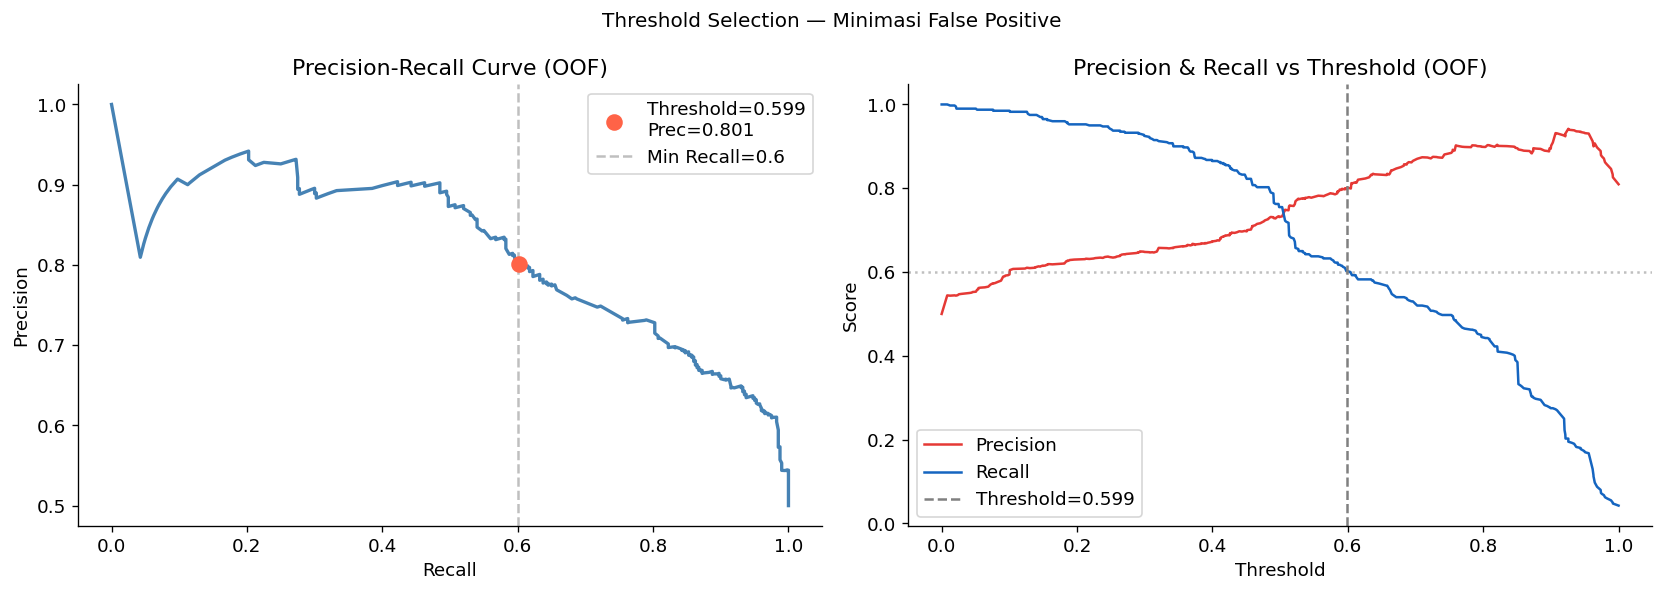

In [65]:
MIN_RECALL = 0.60

y_prob_oof = cross_val_predict(
    calibrated_model, X_train_smote, y_train_smote,
    cv=cv, method='predict_proba'
)[:, 1]

prec_vals, rec_vals, thresh_vals = precision_recall_curve(y_train_smote, y_prob_oof)

valid_mask = rec_vals[:-1] >= MIN_RECALL
if valid_mask.any():
    best_idx     = np.argmax(prec_vals[:-1][valid_mask])
    best_thresh  = thresh_vals[valid_mask][best_idx]
    best_prec_cv = prec_vals[:-1][valid_mask][best_idx]
    best_rec_cv  = rec_vals[:-1][valid_mask][best_idx]
else:
    f1_vals = 2 * prec_vals[:-1] * rec_vals[:-1] / (prec_vals[:-1] + rec_vals[:-1] + 1e-9)
    best_idx     = np.argmax(f1_vals)
    best_thresh  = thresh_vals[best_idx]
    best_prec_cv = prec_vals[best_idx]
    best_rec_cv  = rec_vals[best_idx]
    print('Fallback ke F1-optimal')

print(f'Threshold optimal (OOF): {best_thresh:.4f}')
print(f'Precision OOF:           {best_prec_cv:.4f}')
print(f'Recall    OOF:           {best_rec_cv:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rec_vals, prec_vals, color='steelblue', lw=2)
axes[0].scatter([best_rec_cv], [best_prec_cv], color='tomato', zorder=5, s=80,
                label=f'Threshold={best_thresh:.3f}\nPrec={best_prec_cv:.3f}')
axes[0].axvline(MIN_RECALL, ls='--', color='gray', alpha=0.5, label=f'Min Recall={MIN_RECALL}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (OOF)'); axes[0].legend()

axes[1].plot(thresh_vals, prec_vals[:-1], label='Precision', color='#E53935')
axes[1].plot(thresh_vals, rec_vals[:-1],  label='Recall',    color='#1565C0')
axes[1].axvline(best_thresh, ls='--', color='gray', label=f'Threshold={best_thresh:.3f}')
axes[1].axhline(MIN_RECALL, ls=':', color='gray', alpha=0.5)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold (OOF)'); axes[1].legend()

plt.suptitle('Threshold Selection — Minimasi False Positive', fontsize=12)
plt.tight_layout(); plt.show()

---
## 11. Evaluasi Final pada Test Set

In [66]:
y_pred_test = (y_prob_test_cal >= best_thresh).astype(int)

print('=' * 55)
print(f'CLASSIFICATION REPORT — Test Set')
print(f'Model: {final_model_name} + Isotonic Cal.')
print(f'Threshold: {best_thresh:.4f}')
print('=' * 55)
print(classification_report(y_test, y_pred_test, target_names=['Tidak Diabetes', 'Diabetes']))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print(f'ROC-AUC    : {roc_auc_score(y_test, y_prob_test_cal):.4f}')
print(f'Avg Prec   : {average_precision_score(y_test, y_prob_test_cal):.4f}')
print(f'\n  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'  False Positive Rate  : {fp/(fp+tn):.4f}')
print(f'  False Discovery Rate : {fp/(fp+tp+1e-9):.4f}')

CLASSIFICATION REPORT — Test Set
Model: Stacking Ensemble + Isotonic Cal.
Threshold: 0.5988
                precision    recall  f1-score   support

Tidak Diabetes       0.75      0.78      0.76       100
      Diabetes       0.56      0.52      0.54        54

      accuracy                           0.69       154
     macro avg       0.66      0.65      0.65       154
  weighted avg       0.68      0.69      0.69       154

ROC-AUC    : 0.7826
Avg Prec   : 0.6187

  TN=78  FP=22  FN=26  TP=28
  False Positive Rate  : 0.2200
  False Discovery Rate : 0.4400


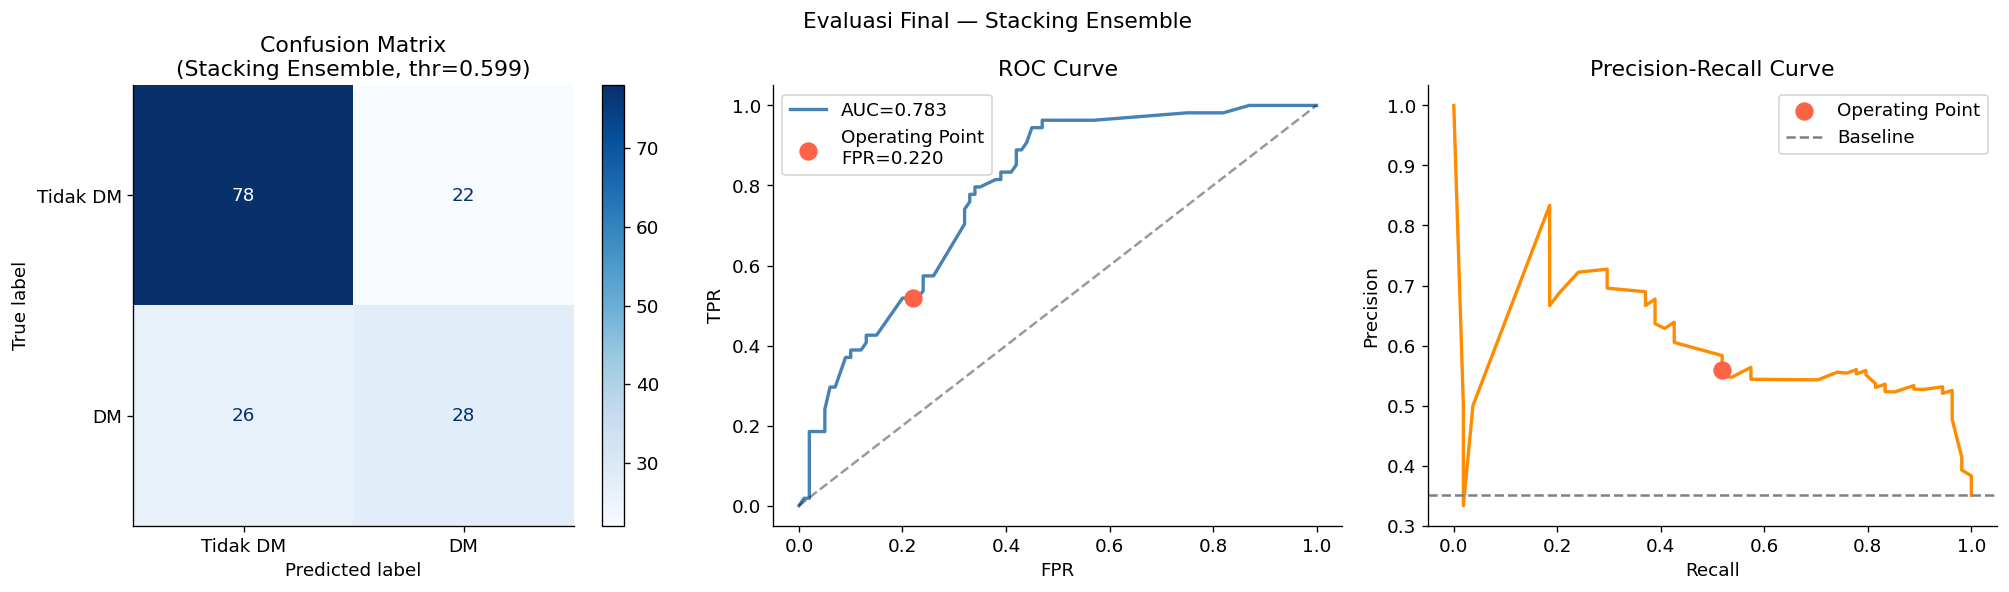

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test, display_labels=['Tidak DM', 'DM'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix\n({final_model_name}, thr={best_thresh:.3f})')

fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob_test_cal)
axes[1].plot(fpr_arr, tpr_arr, lw=2, color='steelblue',
             label=f'AUC={roc_auc_score(y_test, y_prob_test_cal):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].scatter([fp/(fp+tn)], [tp/(tp+fn)], color='tomato', zorder=5, s=100,
                label=f'Operating Point\nFPR={fp/(fp+tn):.3f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob_test_cal)
axes[2].plot(rec_arr, prec_arr, lw=2, color='darkorange')
axes[2].scatter([tp/(tp+fn)], [tp/(tp+fp+1e-9)], color='tomato', zorder=5, s=100,
                label='Operating Point')
axes[2].axhline(y_test.mean(), ls='--', color='gray', label='Baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

plt.suptitle(f'Evaluasi Final — {final_model_name}', fontsize=13)
plt.tight_layout(); plt.show()

---
## 12. Interpretasi Model dengan SHAP

SHAP — XGBoost (base learner dalam stacking)


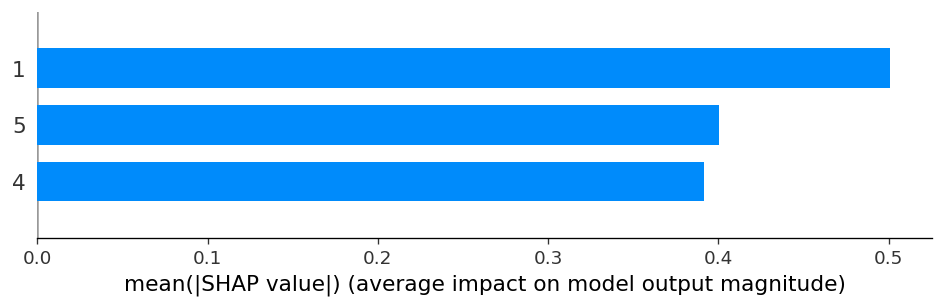

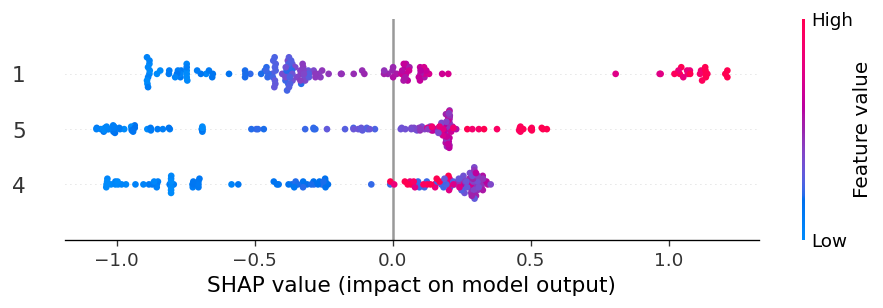

In [68]:
# SHAP pada XGBoost (base model paling interpretatif)
try:
    if final_model_name == 'Stacking Ensemble':
        xgb_base = stacking_clf.named_estimators_['xgb']
    else:
        xgb_base = final_model_uncal

    explainer = shap.Explainer(xgb_base, X_train_smote)
    shap_vals = explainer(X_test_proc)

    print('SHAP — XGBoost (base learner dalam stacking)')
    shap.summary_plot(shap_vals, X_test_proc,
                      feature_names=list(selected_features), plot_type='bar', show=True)
    shap.summary_plot(shap_vals, X_test_proc,
                      feature_names=list(selected_features), show=True)
except Exception as e:
    print(f'SHAP error: {e}')

False Positive: 22 pasien Non-DM diprediksi DM
False Negative: 26 pasien DM terlewat

Waterfall — False Positive (prob=0.6737):


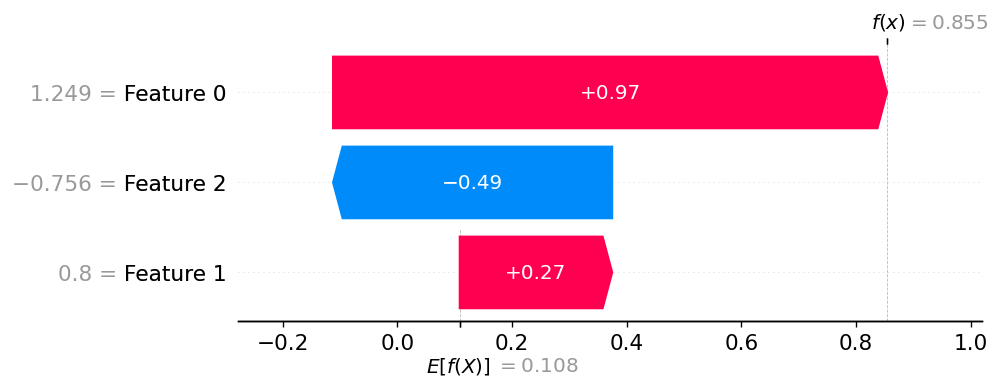

In [69]:
fp_mask = (y_pred_test == 1) & (y_test == 0)
fn_mask = (y_pred_test == 0) & (y_test == 1)
print(f'False Positive: {fp_mask.sum()} pasien Non-DM diprediksi DM')
print(f'False Negative: {fn_mask.sum()} pasien DM terlewat')

try:
    if fp_mask.any():
        fp_idx = np.where(fp_mask)[0][0]
        print(f'\nWaterfall — False Positive (prob={y_prob_test_cal[fp_idx]:.4f}):')
        shap.waterfall_plot(shap_vals[fp_idx])
except:
    pass

---
## 13. Export Model — Pipeline End-to-End yang Terima Raw Data

> Model yang diekspor adalah **satu pipeline lengkap** yang menerima raw DataFrame  
> persis seperti input dari CSV asli — tanpa perlu preprocessing manual di luar.
>
> Pipeline: `raw_df → ZeroToNan → IterativeImputer → Winsorizer → FeatEng → Selector → Scaler → CalibratedModel`

In [70]:
os.makedirs('./model', exist_ok=True)

final_preprocessor = Pipeline(steps=[
    ('zero_to_nan', ZeroToNanImputer(zero_cols=ZERO_COLS)),
    ('imputer',     IterativeImputer(random_state=SEED, max_iter=10)),
    ('winsorizer',  WinsorizerTransformer(lower=0.01, upper=0.99)),
    ('feat_eng',    FeatureEngineeringTransformer()),
    ('selector',    ColumnSelector(columns=list(selected_features))),
    ('scaler',      StandardScaler()),
])
X_all_proc = final_preprocessor.fit_transform(X_raw, y)

X_all_smote, y_all_smote = SMOTE(random_state=SEED).fit_resample(X_all_proc, y)

# Re-build stacking dengan params terbaik
final_stack = StackingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(
            **rs_xgb.best_params_, eval_metric='logloss', random_state=SEED, verbosity=0)),
        ('lgb', lgb.LGBMClassifier(
            **rs_lgb.best_params_, random_state=SEED, verbose=-1)),
        ('rf',  RandomForestClassifier(**rs_rf.best_params_, random_state=SEED)),
        ('et',  ExtraTreesClassifier(**rs_et.best_params_, random_state=SEED)),
        ('gb',  GradientBoostingClassifier(**rs_gb.best_params_, random_state=SEED)),
    ],
    final_estimator=LogisticRegression(C=0.1, max_iter=2000,
                                        class_weight='balanced', random_state=SEED),
    stack_method='predict_proba', passthrough=True, cv=5, n_jobs=-1
)

final_calibrated = CalibratedClassifierCV(final_stack, method='isotonic', cv=5)
final_calibrated.fit(X_all_smote, y_all_smote)
print('Final model re-fit pada semua data.')

Final model re-fit pada semua data.


In [71]:
class DiabetesInferencePipeline:
    REQUIRED_COLS = [
        'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
    ]

    def __init__(self, preprocessor, model, threshold, feature_names, model_name):
        self.preprocessor  = preprocessor
        self.model         = model
        self.threshold     = threshold
        self.feature_names = feature_names
        self.model_name    = model_name

    def _validate(self, df):
        missing = [c for c in self.REQUIRED_COLS if c not in df.columns]
        if missing:
            raise ValueError(f'Kolom tidak ditemukan: {missing}')
        return df[self.REQUIRED_COLS].copy()

    def predict(self, raw_df: pd.DataFrame) -> pd.DataFrame:
        """Prediksi dari raw DataFrame — terima data mentah langsung."""
        df_val = self._validate(raw_df)
        X_proc = self.preprocessor.transform(df_val)
        probs  = self.model.predict_proba(X_proc)[:, 1]
        preds  = (probs >= self.threshold).astype(int)
        return pd.DataFrame({
            'probability': probs.round(4),
            'prediction':  preds,
            'label':       ['Diabetes' if p else 'Tidak Diabetes' for p in preds],
            'confidence':  [
                'Tinggi' if abs(prob - 0.5) > 0.25 else
                'Sedang' if abs(prob - 0.5) > 0.10 else 'Rendah'
                for prob in probs
            ]
        })

    def predict_proba(self, raw_df: pd.DataFrame) -> np.ndarray:
        df_val = self._validate(raw_df)
        return self.model.predict_proba(self.preprocessor.transform(df_val))

    def __repr__(self):
        return (f'DiabetesInferencePipeline(model={self.model_name}, '
                f'threshold={self.threshold:.4f}, n_features={len(self.feature_names)})')


inference_pipeline = DiabetesInferencePipeline(
    preprocessor=final_preprocessor,
    model=final_calibrated,
    threshold=float(best_thresh),
    feature_names=list(selected_features),
    model_name=final_model_name
)

joblib.dump(inference_pipeline, './model/diabetes_inference_pipeline.pkl', compress=3)

metadata = {
    'model_name':            final_model_name,
    'base_learners':         ['XGBoost', 'LightGBM', 'RandomForest', 'ExtraTrees', 'GradBoosting'],
    'meta_learner':          'LogisticRegression (C=0.1, balanced)',
    'smote':                 True,
    'calibration':           'isotonic (CalibratedClassifierCV)',
    'threshold':             float(best_thresh),
    'min_recall_constraint': MIN_RECALL,
    'threshold_method':      'maximize Precision | Recall >= 0.60 | OOF CV',
    'selected_features':     list(selected_features),
    'zero_cols':             ZERO_COLS,
    'test_roc_auc':          round(float(roc_auc_score(y_test, y_prob_test_cal)), 4),
    'test_avg_precision':    round(float(average_precision_score(y_test, y_prob_test_cal)), 4),
    'test_precision':        round(float(precision_score(y_test, y_pred_test)), 4),
    'test_recall':           round(float(recall_score(y_test, y_pred_test)), 4),
    'test_fp':               int(fp),
    'test_fn':               int(fn),
    'test_fpr':              round(float(fp / (fp + tn)), 4),
    'test_fdr':              round(float(fp / (fp + tp + 1e-9)), 4),
}
with open('./model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Tersimpan:')
print('  -> ./model/diabetes_inference_pipeline.pkl')
print('  -> ./model/model_metadata.json')
print()
print(json.dumps(metadata, indent=2))

Tersimpan:
  -> ./model/diabetes_inference_pipeline.pkl
  -> ./model/model_metadata.json

{
  "model_name": "Stacking Ensemble",
  "base_learners": [
    "XGBoost",
    "LightGBM",
    "RandomForest",
    "ExtraTrees",
    "GradBoosting"
  ],
  "meta_learner": "LogisticRegression (C=0.1, balanced)",
  "smote": true,
  "calibration": "isotonic (CalibratedClassifierCV)",
  "threshold": 0.5988095238095237,
  "min_recall_constraint": 0.6,
  "threshold_method": "maximize Precision | Recall >= 0.60 | OOF CV",
  "selected_features": [
    1,
    4,
    5
  ],
  "zero_cols": [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
  ],
  "test_roc_auc": 0.7826,
  "test_avg_precision": 0.6187,
  "test_precision": 0.56,
  "test_recall": 0.5185,
  "test_fp": 22,
  "test_fn": 26,
  "test_fpr": 0.22,
  "test_fdr": 0.44
}


In [72]:
loaded = joblib.load('./model/diabetes_inference_pipeline.pkl')
print(loaded)

sample_raw = pd.DataFrame([
    {'Pregnancies':6, 'Glucose':148, 'BloodPressure':72, 'SkinThickness':35,
     'Insulin':0, 'BMI':33.6, 'DiabetesPedigreeFunction':0.627, 'Age':50},
    {'Pregnancies':1, 'Glucose':89, 'BloodPressure':66, 'SkinThickness':23,
     'Insulin':94, 'BMI':28.1, 'DiabetesPedigreeFunction':0.167, 'Age':21},
    {'Pregnancies':2, 'Glucose':130, 'BloodPressure':0, 'SkinThickness':0,
     'Insulin':0, 'BMI':0, 'DiabetesPedigreeFunction':0.5, 'Age':40},
])

result = loaded.predict(sample_raw)
print('\n' + '=' * 70)
print('HASIL PREDIKSI — Raw Data (zero values otomatis dihandle)')
print('=' * 70)
print(pd.concat([sample_raw[['Glucose', 'BMI', 'Age', 'Insulin']], result], axis=1).to_string(index=False))
print(f'\nThreshold: {loaded.threshold:.4f}')

DiabetesInferencePipeline(model=Stacking Ensemble, threshold=0.5988, n_features=3)

HASIL PREDIKSI — Raw Data (zero values otomatis dihandle)
 Glucose  BMI  Age  Insulin  probability  prediction          label confidence
     148 33.6   50        0       0.7591           1       Diabetes     Tinggi
      89 28.1   21       94       0.0503           0 Tidak Diabetes     Tinggi
     130  0.0   40        0       0.5936           0 Tidak Diabetes     Rendah

Threshold: 0.5988


---
## Ringkasan Perbaikan & Hasil

### Cara Pakai di Produksi

```python
import joblib, pandas as pd

pipeline = joblib.load('./model/diabetes_inference_pipeline.pkl')

# Data mentah — nilai 0 otomatis dihandle sebagai missing
raw_input = pd.DataFrame([{
    'Pregnancies': 2, 'Glucose': 130, 'BloodPressure': 0,
    'SkinThickness': 0, 'Insulin': 0,
    'BMI': 0, 'DiabetesPedigreeFunction': 0.5, 'Age': 40
}])

result = pipeline.predict(raw_input)
# Output: probability | prediction | label | confidence
```
